# Data Cleaning — PA 2022 State Senate Analysis

Goal: produce one clean precinct shapefile with population, racial demographics, and two elections worth of results to feed into the ensemble notebooks

## Data Sources

| Layer | Source |
|---|---|
| 2022 State Senate Districts | [2022 Pennsylvania State Senate Districts Approved Plan](https://redistrictingdatahub.org/dataset/2022-pennsylvania-state-senate-districts-approved-plan/) |
| PA County Boundaries | [2020 TIGER/Line County Shapefiles](https://www.census.gov/geographies/mapping-files/2020/geo/tiger-line-file.html) |
| 2020 Census Blocks (PL 94-171) | [Pennsylvania Block PL 94-171 2020 by Table](https://redistrictingdatahub.org/dataset/pennsylvania-block-pl-94171-2020-by-table/) |
| 2020 General Election Precincts (VEST) | [VEST 2020 Pennsylvania Precinct and Election Results](https://redistrictingdatahub.org/dataset/vest-2020-pennsylvania-precinct-and-election-results/) |
| 2016 General Election Precincts (VEST) | [VEST 2016 Pennsylvania Precinct and Election Results](https://redistrictingdatahub.org/dataset/vest-2016-pennsylvania-precinct-and-election-results/) |

In [16]:
import geopandas as gpd
import maup
import warnings
import os
from pathlib import Path
import pandas as pd
from maup import smart_repair

maup.progress.enabled = True

## Step 1: Set Paths

In [17]:
cwd = Path.cwd()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd

RAW_DATA = str(BASE_DIR / "data" / "raw")
CLEAN_DATA = str(BASE_DIR / "data" / "cleaned")

print("Repo root: ", BASE_DIR)
print("Raw data at: ", RAW_DATA)
print("Clean data at: ", CLEAN_DATA)

Repo root:  /Users/guillermoroque/University-of-San-Francisco/CS-664_AI-For-Redistricting/Final_Project/AI_For_Redistricting_Project
Raw data at:  /Users/guillermoroque/University-of-San-Francisco/CS-664_AI-For-Redistricting/Final_Project/AI_For_Redistricting_Project/data/raw
Clean data at:  /Users/guillermoroque/University-of-San-Francisco/CS-664_AI-For-Redistricting/Final_Project/AI_For_Redistricting_Project/data/cleaned


## Step 2: Load Raw Data

In [18]:
precincts_2020 = gpd.read_file(os.path.join(RAW_DATA, "election", "pa_gen_20_prec", "pa_gen_20_st_sldu_prec.shp"))
precincts_2016 = gpd.read_file(os.path.join(RAW_DATA, "election", "pa_vest_16", "pa_vest_16.shp"))
# P1: Total population per block — provides TOTPOP (P0010001)
blocks_p1 = gpd.read_file(os.path.join(RAW_DATA, "census", "pa_pl2020_b", "pa_pl2020_p1_b.shp"))
# P3: Race by voting age population (18+) — provides VAP (P0030001), WVAP (P0030003), BVAP (P0030004)
blocks_p3 = gpd.read_file(os.path.join(RAW_DATA, "census", "pa_pl2020_b", "pa_pl2020_p3_b.shp"))
# P4: Hispanic/Latino voting age population — provides HVAP (P0040002)
blocks_p4 = gpd.read_file(os.path.join(RAW_DATA, "census", "pa_pl2020_b", "pa_pl2020_p4_b.shp"))
districts = gpd.read_file(os.path.join(RAW_DATA, "districts", "pa_sldu_adopted_2022", "2022 LRC-Senate-Final.shp"))

print("2020 precincts:", precincts_2020.shape, "| CRS:", precincts_2020.crs)
print("2016 precincts:", precincts_2016.shape, "| CRS:", precincts_2016.crs)
print("Blocks p1:", blocks_p1.shape, "| CRS:", blocks_p1.crs)
print("Blocks p3:", blocks_p3.shape, "| CRS:", blocks_p3.crs)
print("Blocks p4:", blocks_p4.shape, "| CRS:", blocks_p4.crs)
print("Districts:", districts.shape, "| CRS:", districts.crs)

2020 precincts: (9150, 93) | CRS: EPSG:4269
2016 precincts: (9166, 25) | CRS: EPSG:4269
Blocks p1: (336985, 77) | CRS: EPSG:4269
Blocks p3: (336985, 77) | CRS: EPSG:4269
Blocks p4: (336985, 79) | CRS: EPSG:4269
Districts: (50, 49) | CRS: EPSG:4269


## Step 3: Inspect Data

In [19]:
print("Total PA population (blocks p1): ", blocks_p1["P0010001"].sum())
print("Total 2020 Biden votes: ",   precincts_2020["G20PREDBID"].sum())
print("Total 2020 Trump votes: ",   precincts_2020["G20PRERTRU"].sum())
print("Total 2016 Clinton votes: ", precincts_2016["G16PREDCLI"].sum())
print("Total 2016 Trump votes: ",   precincts_2016["G16PRERTRU"].sum())
print("Number of senate districts: ", len(districts))

Total PA population (blocks p1):  13002700
Total 2020 Biden votes:  3460310
Total 2020 Trump votes:  3378096
Total 2016 Clinton votes:  2926156
Total 2016 Trump votes:  2971303
Number of senate districts:  50


## Step 3.5) Census VAP Variable IDs

Verify the Census PL 94-171 variable IDs used for total VAP, racial VAP, and Hispanic VAP. The raw shapefile columns store the Census variable IDs; the descriptive names come from the Census PL table definitions.

In [20]:
vap_sources = [
    {
        "raw_table": "blocks_p3",
        "data": blocks_p3,
        "table_id": "P3",
        "variables": {
            "P0030001": "Total voting-age population",
            "P0030003": "White alone voting-age population",
            "P0030004": "Black or African American alone voting-age population",
        },
    },
    {
        "raw_table": "blocks_p4",
        "data": blocks_p4,
        "table_id": "P4",
        "variables": {
            "P0040002": "Hispanic or Latino voting-age population",
        },
    },
]

rows = []
for source in vap_sources:
    for variable_id, description in source["variables"].items():
        if variable_id not in source["data"].columns:
            raise KeyError(f"{variable_id} missing from {source['raw_table']}")
        rows.append({
            "Variable ID": variable_id,
            "Census Table": source["table_id"],
            "Description": description,
            "Statewide Total": source["data"][variable_id].sum(),
        })

summary = pd.DataFrame(rows)
summary["Statewide Total"] = summary["Statewide Total"].map("{:,.0f}".format)
summary

,Variable ID,Census Table,Description,Statewide Total
0,P0030001,P3,Total voting-age population,"10,353,548"
1,P0030003,P3,White alone voting-age population,"8,011,431"
2,P0030004,P3,Black or African American alone voting-age pop...,"1,070,165"
3,P0040002,P4,Hispanic or Latino voting-age population,"704,258"


## Step 4: Reproject to UTM Zone 18N (EPSG:32618)

PA sits in UTM Zone 18N — needed for `smart_repair`'s `min_rook_length` to work in meters. Also join the three block tables (p1, p3, p4) into one GeoDataFrame here

In [21]:
precincts_utm  = precincts_2020.to_crs(epsg=32618)
precincts16_utm = precincts_2016.to_crs(epsg=32618)
districts_utm  = districts.to_crs(epsg=32618)

# Reproject blocks and merge p1, p3, p4 attributes into one GeoDataFrame.
blocks_utm = blocks_p1.to_crs(epsg=32618)[["GEOID20", "P0010001", "geometry"]].copy()
# P0030001: Total voting-age population → VAP
# P0030003: White alone VAP → WVAP
# P0030004: Black or African American alone VAP → BVAP
blocks_utm = blocks_utm.merge(blocks_p3[["GEOID20", "P0030001", "P0030003", "P0030004"]], on="GEOID20", validate="one_to_one")
# P0040002: Hispanic or Latino VAP → HVAP
blocks_utm = blocks_utm.merge(blocks_p4[["GEOID20", "P0040002"]], on="GEOID20", validate="one_to_one")

print("All layers reprojected to UTM Zone 18N (EPSG:32618)")
print("Blocks columns:", list(blocks_utm.columns))
print("Block rows after merge:", len(blocks_utm), "| original P1 rows:", len(blocks_p1))
print("Missing VAP fields after merge:", blocks_utm[["P0030001", "P0030003", "P0030004", "P0040002"]].isna().sum().to_dict())

All layers reprojected to UTM Zone 18N (EPSG:32618)
Blocks columns: ['GEOID20', 'P0010001', 'geometry', 'P0030001', 'P0030003', 'P0030004', 'P0040002']
Block rows after merge: 336985 | original P1 rows: 336985
Missing VAP fields after merge: {'P0030001': 0, 'P0030003': 0, 'P0030004': 0, 'P0040002': 0}


## Step 5: Load Direct County Boundaries

Use an official county boundary shapefile directly. This gives `smart_repair` an authoritative county layer for `nest_within_regions` and avoids deriving counties by dissolving block geometries.

Number of PA counties: 67
County CRS: EPSG:32618


<Axes: >

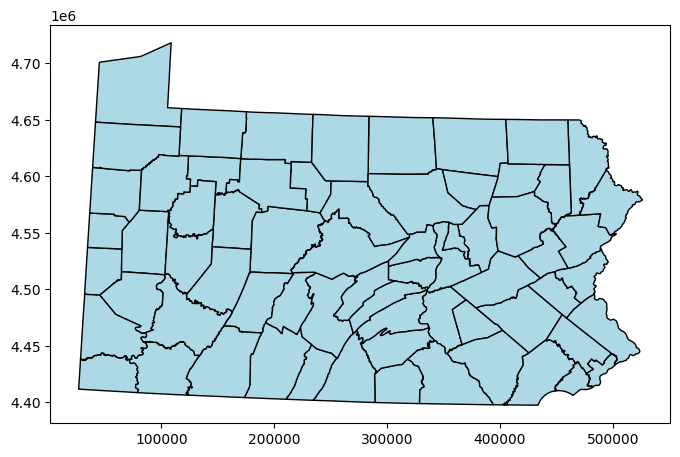

In [22]:
county_path = os.path.join(RAW_DATA, "counties", "tl_2020_us_county", "tl_2020_us_county.shp")

if not os.path.exists(county_path):
    raise FileNotFoundError(
        "County shapefile not found. Place the 2020 TIGER/Line national county file at "
        f"{county_path}"
    )

counties = gpd.read_file(county_path)
counties = counties[counties["STATEFP"] == "42"].copy()
counties_utm = counties.to_crs(epsg=32618)

print("Number of PA counties:", len(counties_utm))
print("County CRS:", counties_utm.crs)
counties_utm.plot(figsize=(8, 8), edgecolor="black", color="lightblue")

## Step 6: Repair Topology

`nest_within_regions` keeps precincts from crossing county lines. `min_rook_length=30` removes shared boundaries under 30m that are digitization noise rather than real borders

100%|██████████| 67/67 [00:00<00:00, 107.11it/s]


Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.


100%|██████████| 67/67 [00:00<00:00, 176.57it/s]


Identifying overlaps...


100%|██████████| 12370/12370 [00:12<00:00, 998.78it/s] 


...

Gaps to simplify in region 47: 100%|██████████| 1/1 [00:00<00:00, 54.61it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 108: 100%|██████████| 7/7 [00:00<00:00, 41.18it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 165: 100%|██████████| 1/1 [00:00<00:00, 40.68it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 242: 100%|██████████| 1/1 [00:00<00:00, 28.31it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 503: 100%|██████████| 2/2 [00:00<00:00, 35.51it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 599: 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 821: 100%|██████████| 1/1 [00:00<00:00, 57.95it/s]
Gaps to fill: 

Converting small rook adjacencies to queen...


100%|██████████| 9150/9150 [00:14<00:00, 635.10it/s]



Repaired precincts pass maup.doctor? True


<Axes: >

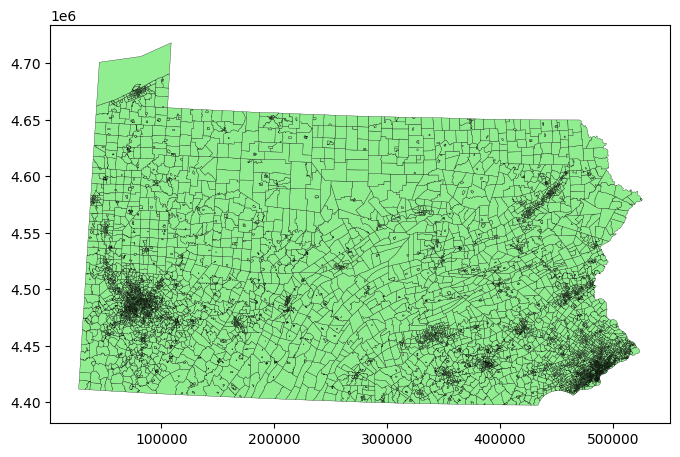

In [23]:
precincts_repaired = smart_repair(precincts_utm, nest_within_regions=counties_utm, min_rook_length=30)

print("\nRepaired precincts pass maup.doctor?", maup.doctor(precincts_repaired))
precincts_repaired.plot(figsize=(8, 8), edgecolor="black", linewidth=0.2, color="lightgreen")

## Step 7: Assign Blocks to Precincts

This assignment is reused for population, VAP, and prorated 2016 vote aggregation below.

In [24]:
blocks_to_precincts = maup.assign(blocks_utm.geometry, precincts_repaired.geometry)

unassigned_blocks = blocks_to_precincts.isna().sum()
print(f"Unassigned blocks: {unassigned_blocks} out of {len(blocks_utm)}")

100%|██████████| 9150/9150 [00:54<00:00, 168.13it/s]


Unassigned blocks: 0 out of 336985


## Step 8: Aggregate Population to Precincts

In [25]:
precincts_repaired["TOTPOP"] = blocks_utm["P0010001"].groupby(blocks_to_precincts).sum()

print("Total population in blocks:   ", blocks_utm["P0010001"].sum())
print("Total population in precincts:", precincts_repaired["TOTPOP"].sum())

Total population in blocks:    13002700
Total population in precincts: 13002700


## Step 9: Aggregate VAP, Racial VAP, and Hispanic VAP to Precincts

Use Census PL 94-171 P3 variables for total VAP (P0030001), WVAP (P0030003), and BVAP (P0030004), and the P4 Hispanic-or-Latino variable for HVAP (P0040002).

In [26]:
vap_cols = [
    ("P0030001", "VAP"),   # P0030001: Total voting-age population
    ("P0030003", "WVAP"),  # P0030003: White alone VAP
    ("P0030004", "BVAP"),  # P0030004: Black or African American alone VAP
    ("P0040002", "HVAP"),  # P0040002: Hispanic or Latino VAP
]

for col_in, col_out in vap_cols:
    precincts_repaired[col_out] = blocks_utm[col_in].groupby(blocks_to_precincts).sum()

print("VAP total:", precincts_repaired["VAP"].sum())
print("WVAP total:", precincts_repaired["WVAP"].sum())
print("BVAP total:", precincts_repaired["BVAP"].sum())
print("HVAP total:", precincts_repaired["HVAP"].sum())

VAP total: 10353548
WVAP total: 8011431
BVAP total: 1070165
HVAP total: 704258


## Step 10: Assign Senate Districts to Precincts

Any precincts that don't fall inside a district polygon get snapped to the nearest one so nothing is left unassigned

In [27]:
precincts_to_districts = maup.assign(precincts_repaired.geometry, districts_utm.geometry)
precincts_repaired["SENDIST"] = precincts_to_districts.map(districts_utm["DISTRICT"])

unassigned_mask = precincts_repaired["SENDIST"].isna()
n_unassigned = unassigned_mask.sum()
print(f"Unassigned precincts: {n_unassigned}")

if n_unassigned > 0:
    print("Fixing unassigned precincts by nearest district...")
    for idx in precincts_repaired[unassigned_mask].index:
        centroid = precincts_repaired.loc[idx, "geometry"].centroid
        nearest  = districts_utm.geometry.distance(centroid).idxmin()
        precincts_repaired.loc[idx, "SENDIST"] = districts_utm.loc[nearest, "DISTRICT"]
    print(f"Remaining unassigned after fix: {precincts_repaired['SENDIST'].isna().sum()}")

precincts_repaired["SENDIST"] = precincts_repaired["SENDIST"].astype("Int64")
print("Senate districts assigned:", precincts_repaired["SENDIST"].nunique())

100%|██████████| 50/50 [00:03<00:00, 16.32it/s]

Unassigned precincts: 0
Senate districts assigned: 50


## Step 11: Transfer 2016 Votes to 2020 Precinct Boundaries

2016 VEST precincts have different boundaries than 2020, so we disaggregate 2016 votes to census blocks using VAP weights, then reaggregate up to 2020 precincts

In [28]:
# Assign census blocks to 2016 VEST precincts.
blocks_to_vest16 = maup.assign(blocks_utm.geometry, precincts16_utm.geometry)

print(f"Blocks unassigned to a 2016 precinct: {blocks_to_vest16.isna().sum()}")

# Weight = block VAP / total VAP of all blocks assigned to the same 2016 precinct.
weights_2016 = blocks_utm["P0030001"] / blocks_to_vest16.map(blocks_utm["P0030001"].groupby(blocks_to_vest16).sum())
weights_2016 = weights_2016.fillna(0)

# Disaggregate 2016 votes from 2016 precincts down to blocks.
prorated_2016 = maup.prorate(blocks_to_vest16, precincts16_utm[["G16PREDCLI", "G16PRERTRU"]], weights_2016)
blocks_utm[["PRES16D", "PRES16R"]] = prorated_2016.rename(columns={"G16PREDCLI": "PRES16D", "G16PRERTRU": "PRES16R"})

print("2016 Clinton — original:", precincts_2016["G16PREDCLI"].sum(), "| after prorate:", round(blocks_utm["PRES16D"].sum()))
print("2016 Trump   — original:", precincts_2016["G16PRERTRU"].sum(), "| after prorate:", round(blocks_utm["PRES16R"].sum()))

# Aggregate block-level 2016 votes up to repaired 2020 precincts.
elec2016_cols = ["PRES16D", "PRES16R"]
precincts_repaired[elec2016_cols] = blocks_utm[elec2016_cols].groupby(blocks_to_precincts).sum()

print("\n2016 Clinton in 2020 precincts:", round(precincts_repaired["PRES16D"].sum()))
print("2016 Trump   in 2020 precincts:", round(precincts_repaired["PRES16R"].sum()))

100%|██████████| 9166/9166 [00:12<00:00, 714.67it/s] 


Blocks unassigned to a 2016 precinct: 0
2016 Clinton — original: 2926156 | after prorate: 2926156
2016 Trump   — original: 2971303 | after prorate: 2971303

2016 Clinton in 2020 precincts: 2926156
2016 Trump   in 2020 precincts: 2971303


## Step 12: Build Final Shapefile

Keeping only the columns the ensemble notebooks need and rename to clean conventions

| Column | Description |
|---|---|
| `COUNTYFP` | County FIPS code |
| `TOTPOP` | 2020 total population |
| `VAP` | Total voting-age population (18+) |
| `BVAP` | Black or African American alone voting-age population |
| `WVAP` | White alone voting-age population |
| `HVAP` | Hispanic/Latino voting-age population |
| `PRES20D` | 2020 Biden votes |
| `PRES20R` | 2020 Trump votes |
| `PRES16D` | 2016 Clinton votes |
| `PRES16R` | 2016 Trump votes |
| `SENDIST` | 2022 Senate district ID |
| `geometry` | Precinct polygon |

In [29]:
final_precincts = precincts_repaired[[
    "COUNTYFP",
    "TOTPOP",
    "VAP",
    "BVAP",
    "WVAP",
    "HVAP",
    "G20PREDBID",
    "G20PRERTRU",
    "PRES16D",
    "PRES16R",
    "SENDIST",
    "geometry"
]].copy()

final_precincts = final_precincts.rename(columns={
    "G20PREDBID": "PRES20D",
    "G20PRERTRU": "PRES20R"
})

print("Final shapefile shape:", final_precincts.shape)
print("Columns:", list(final_precincts.columns))
print("\n{}".format(final_precincts.head()))

Final shapefile shape: (9150, 12)
Columns: ['COUNTYFP', 'TOTPOP', 'VAP', 'BVAP', 'WVAP', 'HVAP', 'PRES20D', 'PRES20R', 'PRES16D', 'PRES16R', 'SENDIST', 'geometry']

  COUNTYFP  TOTPOP   VAP  BVAP  WVAP  HVAP  PRES20D  PRES20R  PRES16D  \
0      001    1022   744     4   651    83      137      345    119.0   
1      001     867   634     9   544    97      175      275    143.0   
2      001     736   519     7   363   163      102      202     83.0   
3      001    2403  1971    29  1788    70      374      954    257.0   
4      001    1225   926    15   758   141      193      366    148.0   

   PRES16R  SENDIST                                           geometry  
0    274.0       33  POLYGON ((329155.079 4416748.077, 329211.065 4...  
1    235.0       33  POLYGON ((302477.442 4422130.006, 303019.281 4...  
2    153.0       33  POLYGON ((307368.82 4428057.592, 307403.722 44...  
3    816.0       33  MULTIPOLYGON (((329155.079 4416748.077, 329144...  
4    314.0       33  POLYGON ((

## Step 13: Save Cleaned Shapefile

In [30]:
output_dir = os.path.join(CLEAN_DATA, "pa_cleaned_precincts")
os.makedirs(output_dir, exist_ok=True)

final_precincts.to_file(os.path.join(output_dir, "pa_cleaned_precincts.shp"))
print("Saved cleaned shapefile to:", output_dir)

Saved cleaned shapefile to: /Users/guillermoroque/University-of-San-Francisco/CS-664_AI-For-Redistricting/Final_Project/AI_For_Redistricting_Project/data/cleaned/pa_cleaned_precincts
